# Condensed Notebook

This is a condensed version of the original HyyLabNotebook with code not critical to the core function of the notebook removed. If you need further information on any of the cells/functions in this notebook, consult the original HyyLabNotebook

# The Experiment
This experiment uses custom modules in the *backend* folder, which have been specifically developed for this third-year lab. This notebook works with **pre-processed data** derived from the **13 TeV 2025 ATLAS Open Data**.

Please run the cell below to install the required packages. You will need to do this **each time you start the server**.

In [1]:
!pip install atlasopenmagic
!pip install pyarrow==20.0.0

from atlasopenmagic import install_from_environment
install_from_environment(environment_file="../backend/environment.yml")

Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.8.5', 'awkward-pandas>=2023.8.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook>=7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex>=3.1.0', 'vector>=1.4.1']


Installation complete. You may need to restart your Python environment for changes to take effect.


The above cell is likely to take about 30 seconds to run. Wait until the [*] to the left of the above cell becomes a number, indicating that it has finished running. Then, run the cell below to import the required modules and functions for the experiment. Repeat this step **every time you restart the kernel**.

In [2]:
import os
import re
import awkward as ak
import time
import datetime
from zoneinfo import ZoneInfo
import uproot
import glob
import numpy as np
import vector
import hist
from hist import Hist
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator # for minor ticks
from lmfit import fit_report
from lmfit.models import PolynomialModel, GaussianModel
import pyarrow.parquet as pq
import sys
sys.path.append('../')
from backend import get_valid_variables, validate_read_variables
from backend import plot_stacked_hist, plot_histograms, histogram_2d, plot_errorbars
from backend import get_histogram, analysis_parquet, VALID_STR_CODE, produced_event_count

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 880.80datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


# Finding the last opened file

This function allows us to open the parquet file we have just written. By writing and reading parquet files, less data is kept in RAM, allowing for a larger proportion of data to be handled and the program to run faster.

In [3]:
def get_latest_output_path(base_folder='output'):
    # Search for all subfolders in the output directory
    search_path = os.path.join(base_folder, 'analysis_parquet*')
    list_of_folders = glob.glob(search_path)
    
    if not list_of_folders:
        raise FileNotFoundError(f"No output folders found in {base_folder}")
        
    # Return the folder with the most recent modification time
    latest_folder = max(list_of_folders, key=os.path.getmtime)
    return latest_folder

# Optimise Cuts

Keep varying the cut parameters until the highest ratio of signal/sqrt(background) is achieved.

In [4]:
"""from scipy.optimize import differential_evolution

# --- 2. UNIFIED CUT FUNCTION ---
def yy_cut_flexible(data, params):

    #Applies selection cuts based on parameters provided by the optimizer.
    #params: [mass_low, ptcone_limit, topoet_limit1, topoet_limit2]
    
    m_low, m_high, ptc1, ptc2, etc1, etc2, pt1_low, pt2_low = params
    
    # 3. Calculate Mass
    four_momentum = vector.zip({
        'pt': data['photon_pt'], 'eta': data['photon_eta'],
        'phi': data['photon_phi'], 'E': data['photon_e']
    })
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M

    # 4. Flexible Cuts based on params
    mask = (data['mass'] >= m_low) & (data['mass'] <= m_high) & \
           (data['photon_ptcone20'][:, 0] <= ptc1) & (data['photon_ptcone20'][:, 1] <= ptc2) & \
           (data['photon_topoetcone40'][:, 0] <= etc1) & (data['photon_topoetcone40'][:, 1] <= etc2) & \
           (data['photon_pt'][:, 0] >= pt1_low) & (data['photon_pt'][:, 1] <= pt2_low)
    
    data = data[mask]
    
    return data


def pre_selection(data):
    data = data[data['photon_n'] == 2]
    mask_real = (data['photon_isTightID'][:, 0] == 1) & (data['photon_isTightID'][:, 1] == 1)
    data = data[mask_real]
    # Calculate mass so it's available for the optimizer
    four_momentum = vector.zip({
        'pt': data['photon_pt'], 'eta': data['photon_eta'],
        'phi': data['photon_phi'], 'E': data['photon_e']
    })
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M

    mask_iso = (data['photon_isLooseIso'][:, 0] == 1) & (data['photon_isLooseIso'][:, 1] == 1)
    data = data[mask_iso]
    
    return data

# --- 1. CONFIGURATION ---
string_code_list = ['GamGam', 'Hyy'] 
read_variables = ['photon_pt', 'photon_eta', 'photon_phi', 'photon_e', 'photon_n', 
                  'photon_ptcone20','photon_topoetcone40','photon_isTightID', 'photon_isLooseIso',
                  'totalWeight']

# --- 3. RUN PROCESSING (INITIAL WRITE) ---
print("--- Initial processing to create base files ---")
# Use a fraction to keep it fast
fraction = 1
# We need to save the data *before* optimization cuts are applied
# so we run analysis_parquet with a function that only does the pre-selection

data = analysis_parquet(
    read_variables, 
    string_code_list, 
    fraction=fraction, 
    cut_function=pre_selection, 
    write_parquet=True, 
    return_output=False
)

# --- 4. LOAD PRE-SELECTED DATA ---
print("--- Loading pre-selected data --- ")
output_dir = get_latest_output_path()
sig_raw = ak.from_parquet(f"{output_dir}/Hyy_{str(fraction).replace('.','_')}")
bkg_raw = ak.from_parquet(f"{output_dir}/GamGam_{str(fraction).replace('.','_')}")

# --- 5. OPTIMIZATION OBJECTIVE FUNCTION ---
def objective(params, sig, bkg):
    # Unpack parameters
    m_low, m_high, ptc1, ptc2, topo1, topo2, pt1, pt2 = params
    
    # 1. Define Trial Cuts
    def apply_trial_cuts(arr):
        mask = (arr['mass'] >= m_low) & (arr['mass'] <= m_high) & \
               (arr['photon_ptcone20'][:, 0] <= ptc1) & (arr['photon_ptcone20'][:, 1] <= ptc2) & \
               (arr['photon_topoetcone40'][:, 0] <= topo1) & (arr['photon_topoetcone40'][:, 1] <= topo2) & \
                (arr['photon_pt'][:, 0] >= pt1) & (arr['photon_pt'][:, 1] >= pt2)
        return arr[mask]

    # 2. Apply to Samples
    s_final = apply_trial_cuts(sig)
    b_final = apply_trial_cuts(bkg)

    # 3. Sum weights (handles weighted and unweighted data)
    s = ak.sum(s_final['totalWeight']) if 'totalWeight' in s_final.fields else len(s_final)
    b = ak.sum(b_final['totalWeight']) if 'totalWeight' in b_final.fields else len(b_final)

    # 4. Significance Formula
    if b <= 0 or s <= 0:
        return 0 # No significance if no events
    
    significance = s / np.sqrt(b)
    
    # 5. Return NEGATIVE to MAXIMIZE
    return -significance

# --- 6. RUN OPTIMIZER ---
print("--- Starting Optimization ---")

bounds = [
    (110.0, 125.0), # mass_low
    (125.0, 140.0), # mass_high
    (5.0, 30.0),    # ptcone1
    (5.0, 30.0),    # ptcone2
    (5.0, 40.0),   # etcone1
    (5.0, 40.0),   # etcone2
    (25.0, 75.0),    # pt1 
    (25.0, 75.0)     # pt2
]

res = differential_evolution(
    objective,
    bounds=bounds,
    args=(sig_raw, bkg_raw),
    maxiter=100,
    popsize=20,
    disp=True
)

print("Optimal Parameters:", res.x)
print("Maximized Significance:", -res.fun)"""

'from scipy.optimize import differential_evolution\n\n# --- 2. UNIFIED CUT FUNCTION ---\ndef yy_cut_flexible(data, params):\n\n    #Applies selection cuts based on parameters provided by the optimizer.\n    #params: [mass_low, ptcone_limit, topoet_limit1, topoet_limit2]\n    \n    m_low, m_high, ptc1, ptc2, etc1, etc2, pt1_low, pt2_low = params\n    \n    # 3. Calculate Mass\n    four_momentum = vector.zip({\n        \'pt\': data[\'photon_pt\'], \'eta\': data[\'photon_eta\'],\n        \'phi\': data[\'photon_phi\'], \'E\': data[\'photon_e\']\n    })\n    data[\'mass\'] = (four_momentum[:, 0] + four_momentum[:, 1]).M\n\n    # 4. Flexible Cuts based on params\n    mask = (data[\'mass\'] >= m_low) & (data[\'mass\'] <= m_high) &            (data[\'photon_ptcone20\'][:, 0] <= ptc1) & (data[\'photon_ptcone20\'][:, 1] <= ptc2) &            (data[\'photon_topoetcone40\'][:, 0] <= etc1) & (data[\'photon_topoetcone40\'][:, 1] <= etc2) &            (data[\'photon_pt\'][:, 0] >= pt1_low) & (data[\'

# Select Data

Create a parquet file with the above (optimised) cuts applied. This file is read in later parts of the code to produce plots, calculate background etc...

In [5]:
string_code_list = ['GamGam', 'Hyy'] # List of dataset codes to load

# Variables to read from the dataset
read_variables = ['photon_pt', 'photon_eta', 'photon_phi', 'photon_e', 'photon_n']

#Other variables for section 7.3
read_variables += ['photon_ptcone20','photon_topoetcone40','photon_isTightID', 'photon_isLooseIso']

# You may also use the pre-defined function `validate_read_variables` to validate your `read_variables`.
read_variables = validate_read_variables(string_code_list, read_variables)

# Custom selection cut function to filter the data
def yy_cut(data):
    # 1. Row Filter: Exactly 2 photons
    data = data[data['photon_n'] == 2]
    
    # 2. Row Filter: Both photons must be "Tight" (ie. real)
    mask_real = (data['photon_isTightID'][:, 0] == 1) & (data['photon_isTightID'][:, 1] == 1)
    data = data[mask_real]
    
    # Define four momentum and Invariant Mass
    four_momentum = vector.zip({
        'pt': data['photon_pt'],
        'eta': data['photon_eta'],
        'phi': data['photon_phi'],
        'E': data['photon_e']
    })
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M
    
    mask_real = ((data['mass'] >= 122.88366078) & (data['mass'] <= 127.82790359))
    data = data[mask_real]

    mask_real = (data['photon_ptcone20'][:, 0] <= 13.35673528) & (data['photon_ptcone20'][:, 1] <= 5.10337893)
    data = data[mask_real]

    mask_real = (data['photon_topoetcone40'][:, 0] <= 24.52077304) & (data['photon_topoetcone40'][:, 1] <= 10.32542659)
    data = data[mask_real]

    mask_real = (data['photon_isLooseIso'][:, 0] == 1) & (data['photon_isLooseIso'][:, 1] == 1)
    data = data[mask_real]
    
    # Isolation variables
    data['photon0_iso_cone1'] = data['photon_ptcone20'][:, 0]
    data['photon1_iso_cone1'] = data['photon_ptcone20'][:, 1]
    
    data['photon0_iso_cone2'] = data['photon_topoetcone40'][:, 0]
    data['photon1_iso_cone2'] = data['photon_topoetcone40'][:, 1]
    
    data['photon0_eta'] = data['photon_eta'][:,0]
    data['photon1_eta'] = data['photon_eta'][:,1]

    data['photon0_pt'] = data['photon_pt'][:,0]
    data['photon1_pt'] = data['photon_pt'][:,1]
    
    return data

fraction = 1
data = analysis_parquet(read_variables, string_code_list, fraction=fraction, cut_function=yy_cut, write_parquet = True, return_output = False)

output_base = get_latest_output_path()

signal_weight_sum = ak.sum(ak.from_parquet(f"{output_base}/Hyy_1")["totalWeight"])

print("Sum of signal weights: " + str(signal_weight_sum))
# Function 'produced_event_count' returns the total number (sum of weights) of generated Monte Carlo events for the data set specified by 'dataKey' and the specificed integrated luminosity.
# You will need this as the denominator in the calculation of the selection efficiency for your signal processes
luminosity = 36.6
produced_event_count('Hyy',luminosity)

efficiency = signal_weight_sum / produced_event_count('Hyy',luminosity)
print("Efficiency " + str(efficiency))

num_signal_events = len(ak.from_parquet(f"{output_base}/GamGam_1"))

Variables validated using ../../parquet/GamGam/chunk_0.parquet
Validate variables using the string code ggF_Hyy
Variables validated using ../../parquet/ggF_Hyy/chunk_0.parquet
Write data to output_directory: output/analysis_parquet26031215171773328644419154
Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 21.0s
Sum of signal weights: 1278.2315588178476
The total number of produced events (sum of weights) for Monte Carlo data set Hyy and luminosity 36.6 inverse femtobarns is 4581
The total number of produced events (sum of weights) for Monte Carlo data set Hyy and luminosity 36.6 inverse femtobarns is 4581
Efficiency 0.27903770797812627


## Plot Stacked Histogram
The dictionary returned by `analysis_parquet` can be used to plot a stacked histogram by passing it to the `plot_stacked_hist` function.

To use this function correctly, there are a few points to take note of:
- The first argument must be a dictionary.
- If a dictionary key includes `'Data'`, its content will be plotted as data points with error bars.
- If a dictionary key includes `'Signal'`, its content will be stacked as histogram bars on top of the background.
- Python strings are case-sensitive, i.e. `'Data'` and `'data'` are treated differently!

An example is shown below, where `'GamGam'` is treated as data and `'Hyy'` as the signal.

Loading data from: output/analysis_parquet26031215171773328644419154
{'Data': <Array [{photon_pt: [...], ...}, ..., {...}] type='42759 * {photon_pt: var ...'>, 'Signal': <Array [{photon_pt: [...], ...}, ..., {...}] type='227824 * {photon_pt: var...'>}
1101.756706413546
Elapsed time = 0.4s


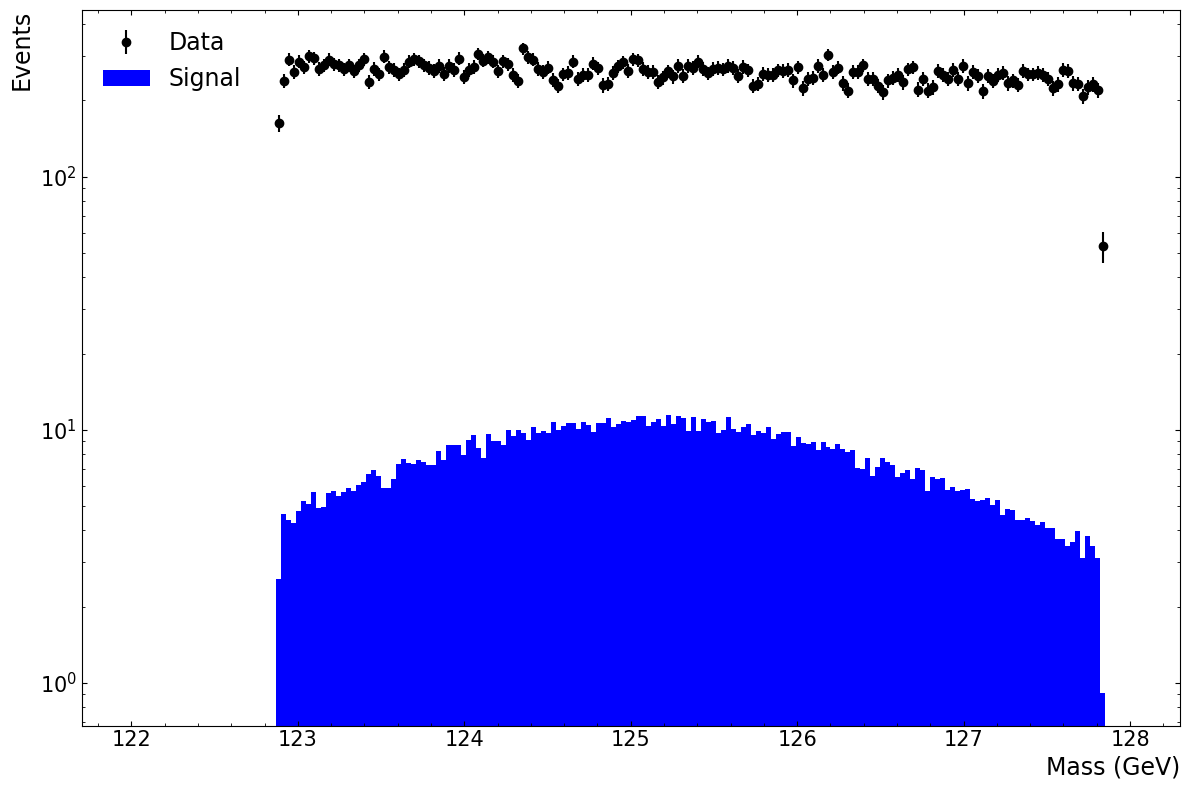

Elapsed time = 0.2s


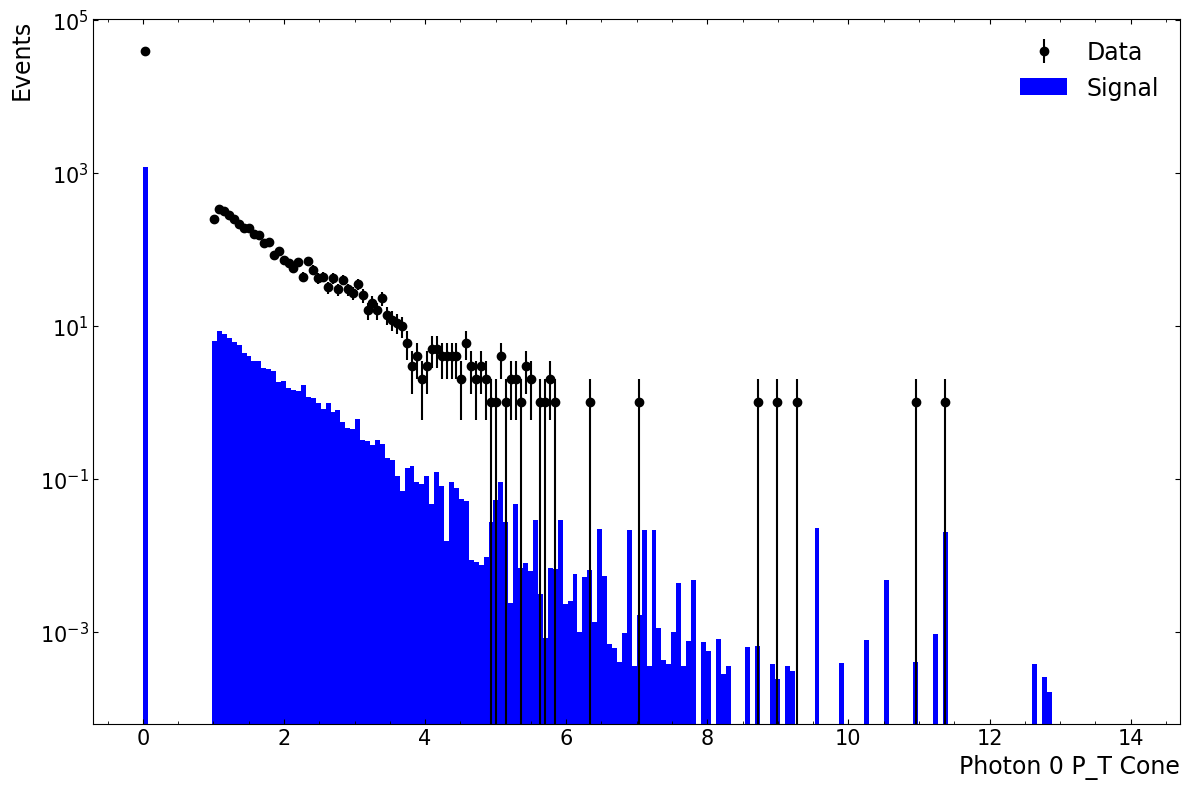

Elapsed time = 0.2s


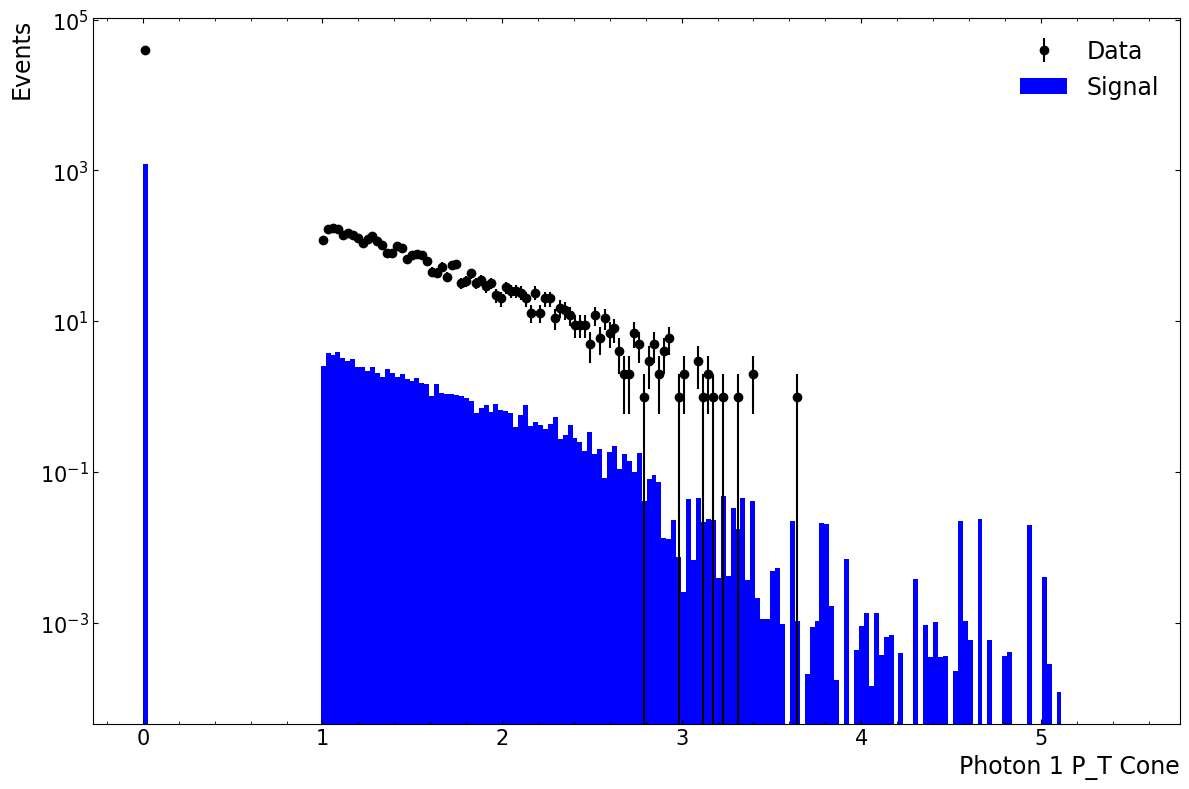

Elapsed time = 0.2s


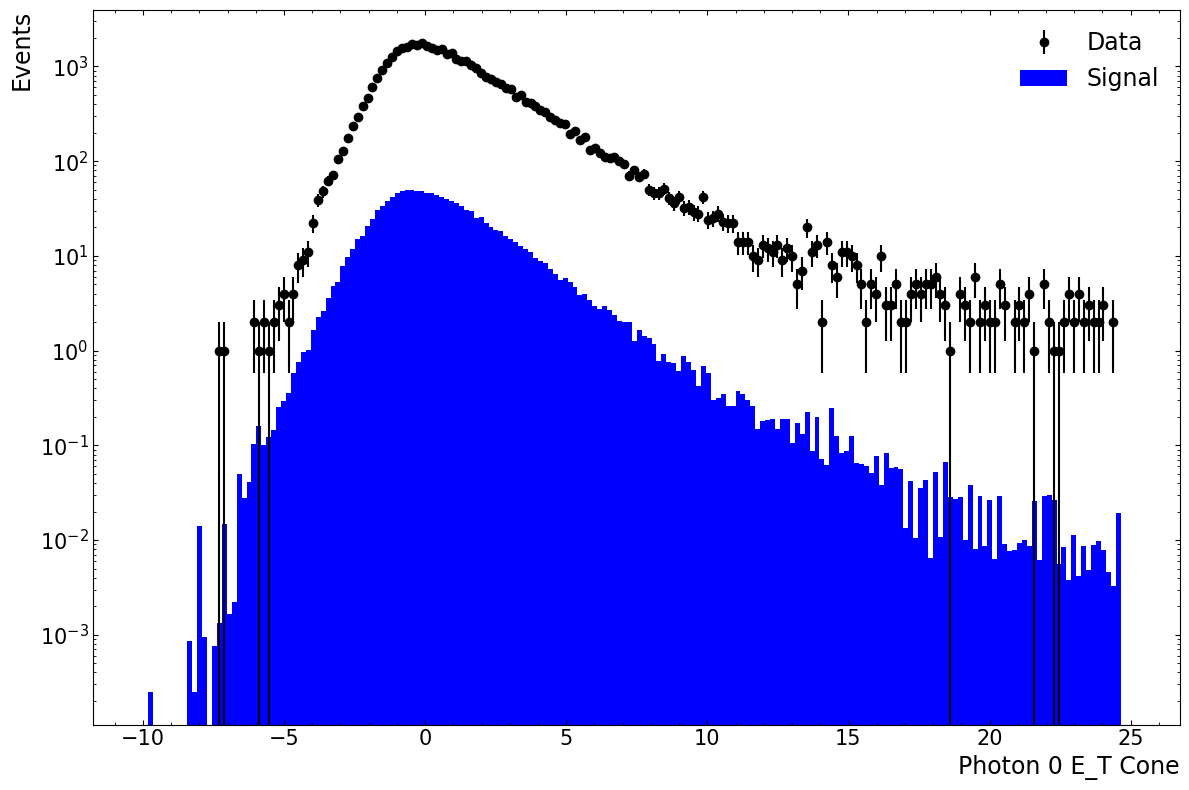

Elapsed time = 0.2s


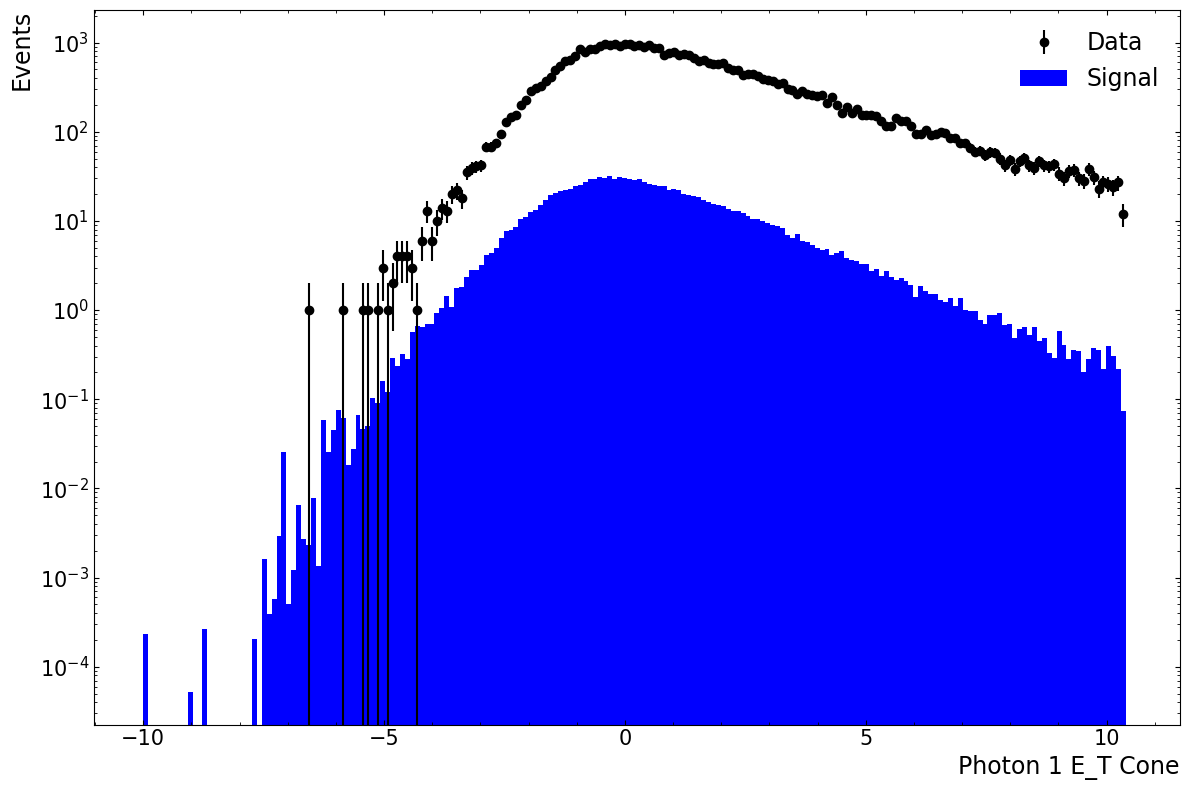

Elapsed time = 0.1s


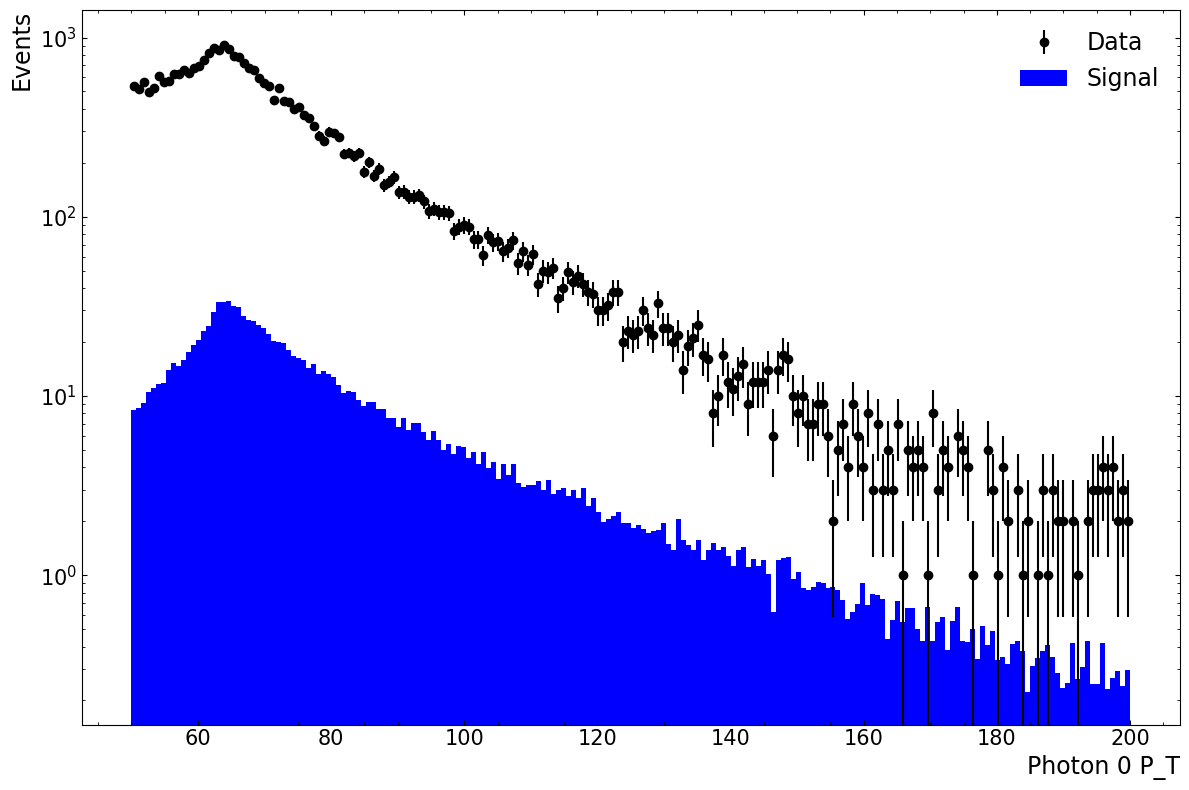

Elapsed time = 0.1s


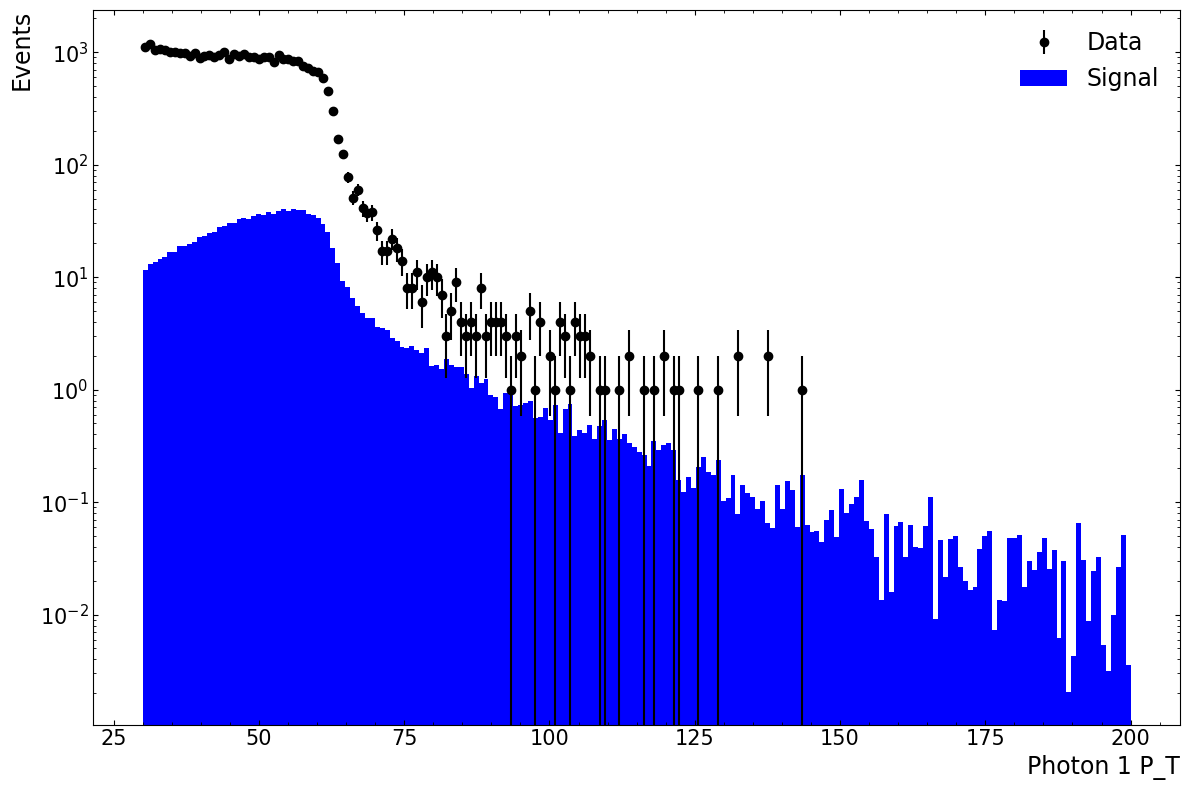

Elapsed time = 0.2s


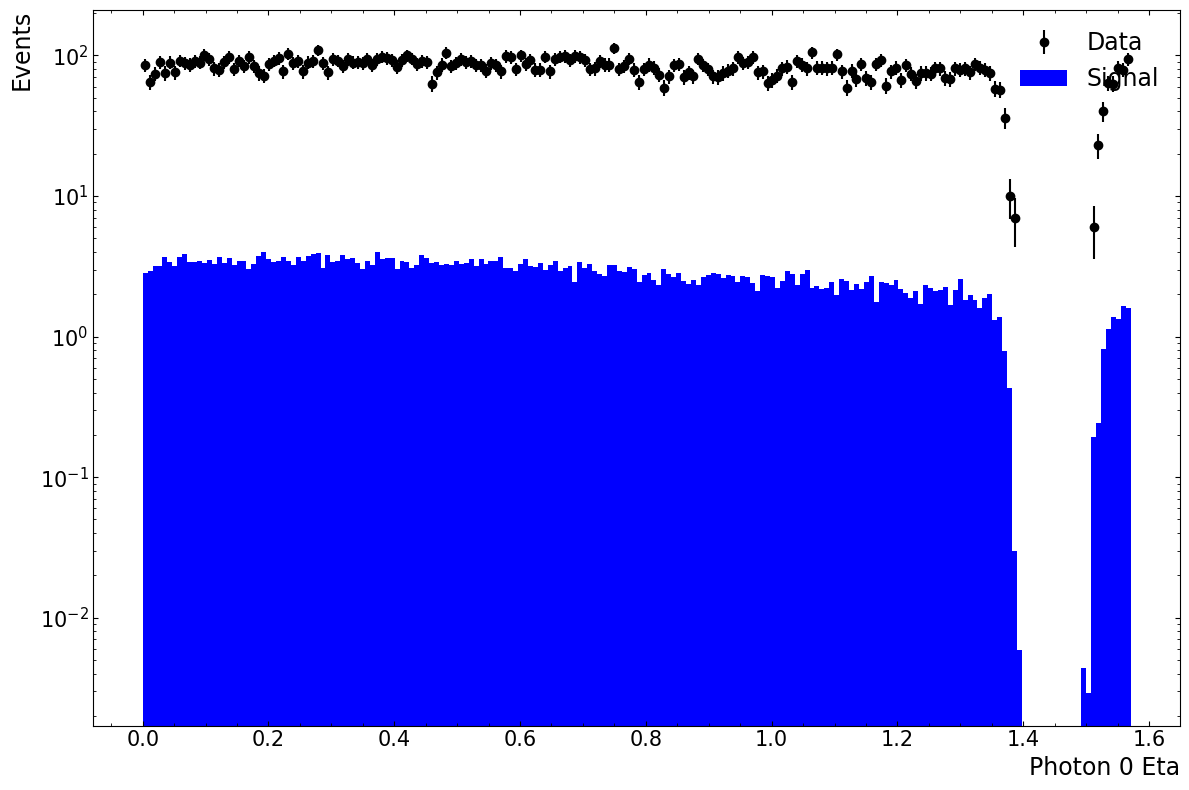

Elapsed time = 0.1s


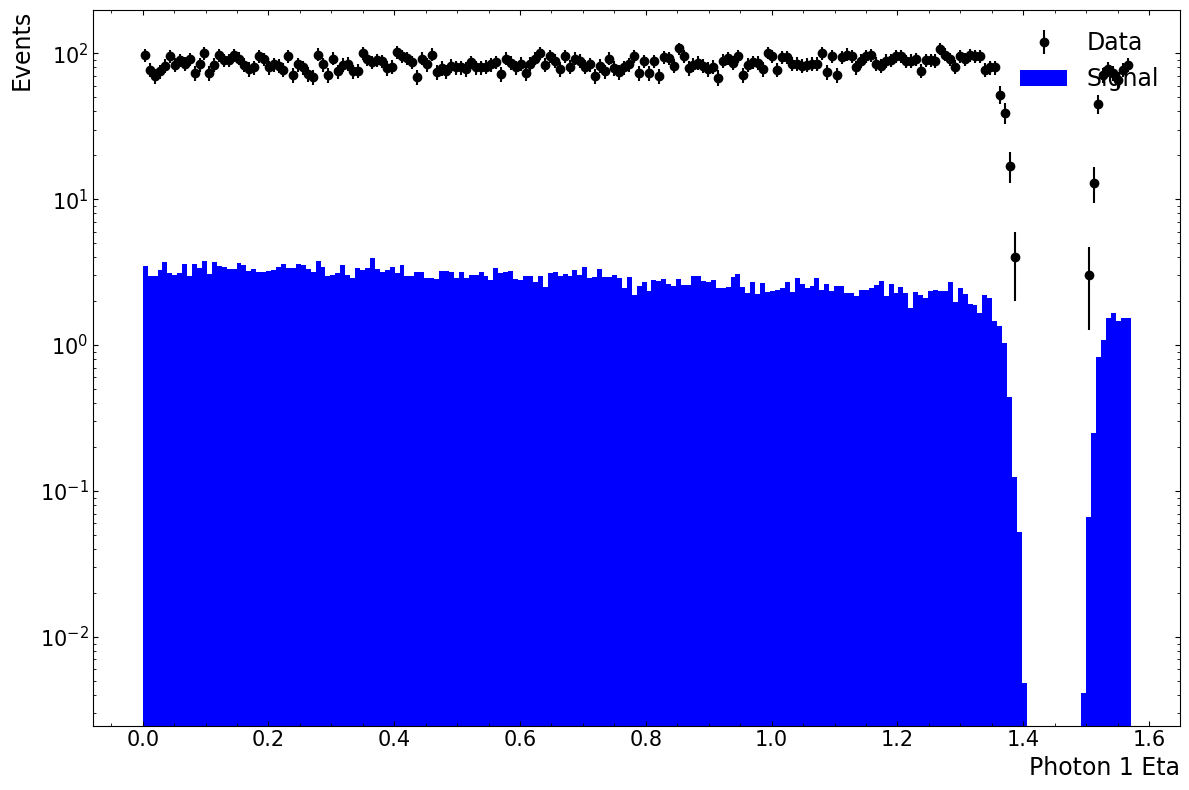

In [6]:
# Define what to plot: 'GamGam' as data, 'Hyy' as signal
print(f"Loading data from: {output_base}")
plot_dict = {
    'Data' :ak.from_parquet(f"{output_base}/GamGam_1"),
    'Signal' : ak.from_parquet(f"{output_base}/Hyy_1")
}
print(plot_dict)

print(len(plot_dict['Signal'])/np.sqrt(len(plot_dict['Data'])))

# Array to hold all the plot variables for each histogram
plot_variables = ['mass',
                  'photon0_iso_cone1',
                  'photon1_iso_cone1',
                  'photon0_iso_cone2',
                  'photon1_iso_cone2',
                  'photon0_pt',
                  'photon1_pt',
                  'photon0_eta',
                  'photon1_eta']

x_labels = ['Mass (GeV)',
            'Photon 0 P_T Cone',
            'Photon 1 P_T Cone',
            'Photon 0 E_T Cone',
            'Photon 1 E_T Cone',
            'Photon 0 P_T',
            'Photon 1 P_T',
            'Photon 0 Eta',
            'Photon 1 Eta']

xmins_and_maxes = [122, 128,
         0, 14,
         0, 5.5,
         -10, 25,
                   -10, 10.5,
                   50, 200,
                   30, 200,
                   0, np.pi/2,
                   0, np.pi/2]

num_bins = 200
color_list = ['k', 'b']
#name_prefix = "Cut_" + str(datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S")) + "_"
name_prefix = "Cut_29_"

if len(xmins_and_maxes) == 2*len(plot_variables):

    for i, plot_var in enumerate(plot_variables):

        fig, hists = plot_stacked_hist(plot_dict, plot_var, color_list, num_bins, xmins_and_maxes[i*2], xmins_and_maxes[i*2+1], x_label = x_labels[i], logy=True, save_fig=True,
                                       fig_name=name_prefix+plot_var)
                   

# Higgs Peak Blinding

Create a new parquet file without the Higgs mass peak to fit the background signal to.

In [7]:
def yy_cut(data):
    # 1. Row Filter: Exactly 2 photons
    data = data[data['photon_n'] == 2]
    
    # 2. Row Filter: Both photons must be "Tight" (ie. real)
    mask_real = (data['photon_isTightID'][:, 0] == 1) & (data['photon_isTightID'][:, 1] == 1)
    data = data[mask_real]
    
    # Define four momentum and Invariant Mass
    four_momentum = vector.zip({
        'pt': data['photon_pt'],
        'eta': data['photon_eta'],
        'phi': data['photon_phi'],
        'E': data['photon_e']
    })
    data['mass'] = (four_momentum[:, 0] + four_momentum[:, 1]).M

    #Change mass cut to remove Higgs peak
    mask_real = (((data['mass'] <= 122) | (data['mass'] >= 128)))
    data = data[mask_real]

    mask_real = (data['photon_ptcone20'][:, 0] <= 13.35673528) & (data['photon_ptcone20'][:, 1] <= 5.10337893)
    data = data[mask_real]

    mask_real = (data['photon_topoetcone40'][:, 0] <= 24.52077304) & (data['photon_topoetcone40'][:, 1] <= 10.32542659)
    data = data[mask_real]

    mask_real = (data['photon_isLooseIso'][:, 0] == 1) & (data['photon_isLooseIso'][:, 1] == 1)
    data = data[mask_real]
    
    # Isolation variables
    data['photon0_iso_cone1'] = data['photon_ptcone20'][:, 0]
    data['photon1_iso_cone1'] = data['photon_ptcone20'][:, 1]
    
    data['photon0_iso_cone2'] = data['photon_topoetcone40'][:, 0]
    data['photon1_iso_cone2'] = data['photon_topoetcone40'][:, 1]
    
    data['photon0_eta'] = data['photon_eta'][:,0]
    data['photon1_eta'] = data['photon_eta'][:,1]

    data['photon0_pt'] = data['photon_pt'][:,0]
    data['photon1_pt'] = data['photon_pt'][:,1]
    
    return data

fraction = 1
data = analysis_parquet(read_variables, string_code_list, fraction=fraction, cut_function=yy_cut, write_parquet = True, return_output = False)

output_base = get_latest_output_path()

print(f"Loading data from: {output_base}")
print(len(ak.from_parquet(f"{output_base}/GamGam_1")['mass']))

# Set histogram parameters
xmin, xmax = 100, 150
bin_size = 0.1
num_bins = int((xmax-xmin)*(1/bin_size))

# Extract mass data from GamGam events
data_mass = ak.from_parquet(f"{output_base}/GamGam_1")['mass']
data_hist_name = 'data mass'

# Get histogram values and bin centres - in this case, the variance is not accessible directly and has to be calculated separately
data_x, _, bin_centres = get_histogram(data_mass, num_bins, xmin, xmax, data_hist_name)
data_x_err = np.sqrt(data_x) # Statistical uncertainties (Poisson)

Write data to output_directory: output/analysis_parquet26031215181773328692507050
Input string_code_list found. Data samples will be accessed by the string code(s).
Elapsed time = 26.4s
Loading data from: output/analysis_parquet26031215181773328692507050
2034708


# Fit Background

Fit the background to the above parquet file.

In [8]:
# Define model components
polynomial_model = PolynomialModel(4) # 4th order polynomial
#gaussian_model = GaussianModel() # Gaussian

# Set initial guesses for polynomial parameters:
# c0 + c1*x + c2*x^2 + c3*x^3 + c4*x^4
parameters = polynomial_model.guess(
    data_x, # data to use to guess parameter values
    x=bin_centres, c0=max(data_x), c1=0, c2=0, c3=0, c4=0
)

# Set initial guesses for Gaussian peak
# parameters += gaussian_model.guess(
#     data_x, # data to use to guess parameter values
#     x=bin_centres, amplitude=100, center=125, sigma=2
# )

# Combine the models
#model = polynomial_model + gaussian_model
model = polynomial_model 

# Fit the model to the data
out = model.fit(data_x, # data to be fit
                parameters, # guesses for the parameters
                x=bin_centres, weights=1/data_x_err, nan_policy='omit') #ASK

# Print out a summary of the fit results
print(fit_report(out))

# Extract background parameters from the fit result
params_dict = out.params.valuesdict()
c0 = params_dict['c0']
c1 = params_dict['c1']
c2 = params_dict['c2']
c3 = params_dict['c3']
c4 = params_dict['c4']

# Get the background-only part of the fit to data
background = (c0 + c1*bin_centres + c2*bin_centres**2 +
              c3*bin_centres**3 + c4*bin_centres**4)

print("Background: " + str(np.sum(background)))

# Extract the full best-fit curve (background + signal)
fit = out.best_fit

[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 25
    # data points      = 440
    # variables        = 5
    chi-square         = 430.078767
    reduced chi-square = 0.98868682
    Akaike info crit   = -0.03479672
    Bayesian info crit = 20.3990769
    R-squared          = 0.54501022
[[Variables]]
    c0:  34227.7505 +/- 11691.9440 (34.16%) (init = 1627)
    c1: -890.498001 +/- 377.799875 (42.43%) (init = 0)
    c2:  9.31209903 +/- 4.55266341 (48.89%) (init = 0)
    c3: -0.04505083 +/- 0.02424962 (53.83%) (init = 0)
    c4:  8.3651e-05 +/- 4.8177e-05 (57.59%) (init = 0)
[[Correlations]] (unreported correlations are < 0.100)
    C(c3, c4) = -0.9997
    C(c2, c3) = -0.9997
    C(c1, c2) = -0.9997
    C(c0, c1) = -0.9997
    C(c2, c4) = +0.9989
    C(c1, c3) = +0.9989
    C(c0, c2) = +0.9988
    C(c1, c4) = -0.9975
    C(c0, c3) = -0.9974
    C(c0, c4) = +0.9955
Background: 455211.5635013593


/tmp/ipykernel_4458/1921384553.py:25: RuntimeWarning: divide by zero encountered in divide
  x=bin_centres, weights=1/data_x_err, nan_policy='omit') #ASK


# Background Results

Plot the background fit and calculate and output the cross section

Reduced chi-square: 0.9886
Elapsed time = 0.1s


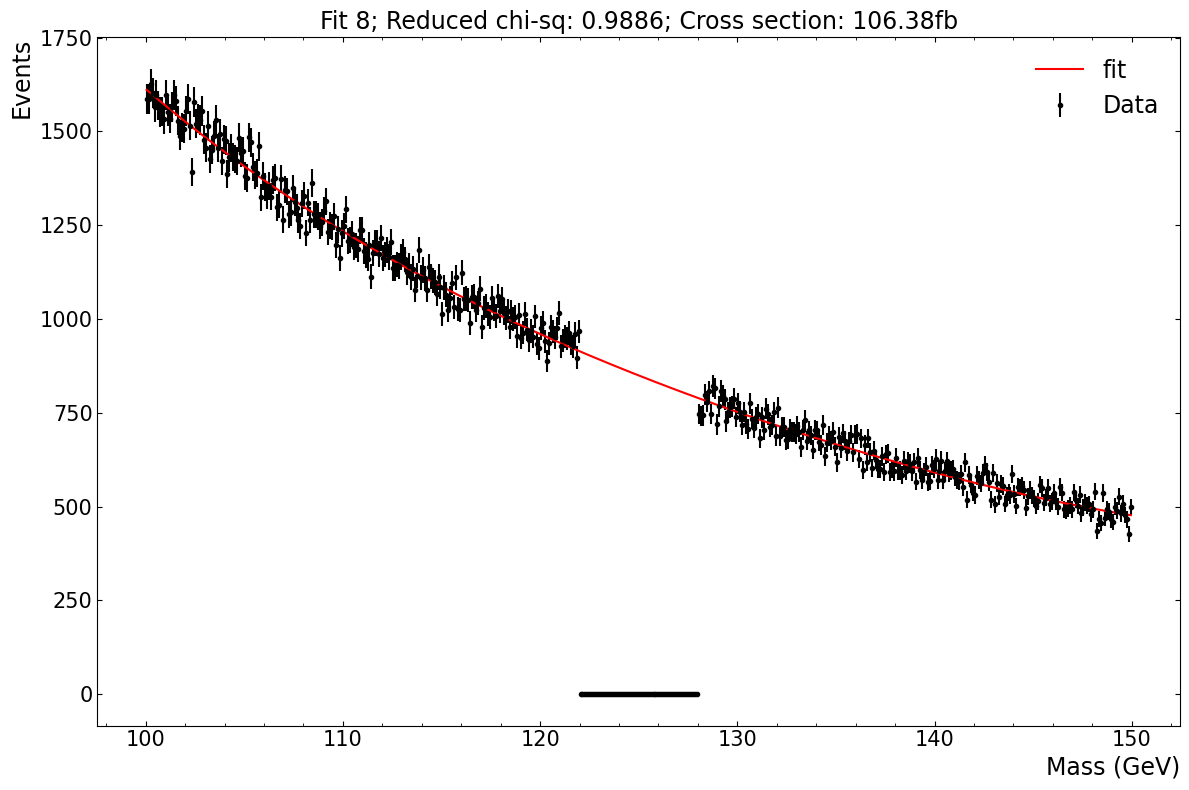

Number of signal events: 42759
Number of background events: 41672
Efficiency: 0.27904
Proportion of non-background events in signal: 0.025408
Cross section: 106.379fb


In [9]:
# Replot the mass distribution and superimpose the fit
# N.B. Use the same num_bins, xmin, xmax as the ones used to make the fit!
plot_dict = {
    'Data' : ak.from_parquet(f"{output_base}/GamGam_1"),
}

#Limits of integration
lower = 122.88366078
upper = 127.82790359

num_background_events = (1/bin_size) * (c0*(upper-lower)+(c1/2)*(upper**2-lower**2)+(c2/3)*(upper**3-lower**3)+(c3/4)*(upper**4-lower**4)+(c4/5)*(upper**5-lower**5))
cross_section = (num_signal_events-num_background_events)/(efficiency*luminosity)

# Variable to plot on the x-axis
plot_variable = 'mass'

fit_number = 8

fit_plot_name = "Fit_" + str(fit_number)

if "." in str(out.redchi)[:5]:
    
    fit_plot_title = "Fit " + str(fit_number) + "; Reduced chi-sq: " + str(out.redchi)[:6] + "; Cross section: " + str(round(cross_section,2)) + "fb"
    print("Reduced chi-square: " + str(out.redchi)[:6])

else:

    fit_plot_title = "Fit " + str(fit_number) + ". Reduced chi-sq: " + str(out.redchi)[:5] + "; Cross section: " + str(round(cross_section,2)) + "fb"
    print("Reduced chi-square: " + str(out.redchi)[:6])
    

# Define plot appearance
color_list = ['k'] # Black (data)
fig, hist = plot_stacked_hist(
    plot_dict, plot_variable, color_list,
    num_bins, xmin, xmax, x_label = "Mass (GeV)",
    fit=fit, title = fit_plot_title, marker='.', save_fig=True,fig_name= fit_plot_name)



print("Number of signal events: " + str(num_signal_events))
print("Number of background events: " + str(int(num_background_events)))
print("Efficiency: " + str(round(efficiency,5)))
print("Proportion of non-background events in signal: " + str(round((num_signal_events-num_background_events)/num_signal_events,6)))

print("Cross section: " + str(round(cross_section,3)) + "fb")